In [1]:
#Librerías
import numpy as np
import matplotlib.pyplot as plt
import h5py

In [2]:
#Constantes físicas
h = 6.62607015e-34 #Constante de Planck (J·s)
c = 2.99792458e8 #Velocidad de la luz (m/s)
k_B = 1.380649e-23 #Constante de Boltzmann (J/K)

In [3]:
def LambdaDom(z, lambda_min, lambda_max, N_lambda):
    '''
    Esta función crea el dominio de longitud de onda
    sin redshift para el espectro. Como al final todos
    los espectros deben tener la misma cantidad de datos
    en el mismo rango, es necesario definir el dominio
    en función de z y los valores de lambda finales con
    ya corridos.
    '''
    lambda_0min = lambda_min/(z+1)
    lambda_0max = lambda_max/(z+1)
    return np.linspace(lambda_0min, lambda_0max, N_lambda) * 1e-9 #lo paso a metros

def blackbody(lambda0_data, T):
    return ((2*h*c**2)/(lambda0_data**5)) / (np.exp((h*c)/(lambda0_data*k_B*T))-1)

def H_lines(lambda0_data, Blackbody_data):
    '''
    Esta función agrega las principales líneas de
    absorción del hidrógeno a un espectro.
    '''
    depth = 0.7
    gamma = 1e-9
    H_alpha = depth*gamma**2 / ((lambda0_data - 656.21e-9  )**2 + gamma**2)
    H_beta = depth*gamma**2 / ((lambda0_data - 486.08e-9  )**2 + gamma**2)
    H_gamma = depth*gamma**2 / ((lambda0_data - 434.00e-9  )**2 + gamma**2)
    H_delta = depth*gamma**2 / ((lambda0_data - 410.13e-9  )**2 + gamma**2)
    lorentzian_profile = H_alpha + H_beta + H_gamma + H_delta
    return Blackbody_data * (1 - lorentzian_profile)

def spectrum_generator(lambda0_data, spectra0_data, z):
    '''
    Esta función genera el espectro sintético a partir
    de los datos de longitud de onda sin redshift, la
    temperatura, la línea de absorción deseada, y el redshift.
    '''
    noise = np.random.normal(0,10**12,len(spectra0_data))
    # lambda_data_shifted = lambda0_data*(1+z)
    # return lambda_data_shifted, spectra0_data + noise
    return spectra0_data + noise

In [4]:
#Parámetros
T = 10000 #Temperatura
z = 0 #Redshift

#Dominio de longitud de onda CON REDSHIFT
z_lambda_min = 400
z_lambda_max = 900
N_lambda = 1000

lambda0_data = LambdaDom(z, z_lambda_min, z_lambda_max, N_lambda)
lambdaDom = (z+1)*lambda0_data

In [5]:
stardata = H_lines(lambda0_data, blackbody(lambda0_data,T))
BRang = spectrum_generator(lambda0_data, stardata, z)

In [6]:
z2 = 0.4 #Redshift

lambda0_data2 = LambdaDom(z2, z_lambda_min, z_lambda_max, N_lambda)
lambdaDom2 = (z2+1)*lambda0_data2
stardata2 = H_lines(lambda0_data2, blackbody(lambda0_data2,T))
BRang2 = spectrum_generator(lambda0_data2, stardata2, z2)

print(lambdaDom[561])
print(lambdaDom2[561])

6.807807807807808e-07
6.807807807807808e-07


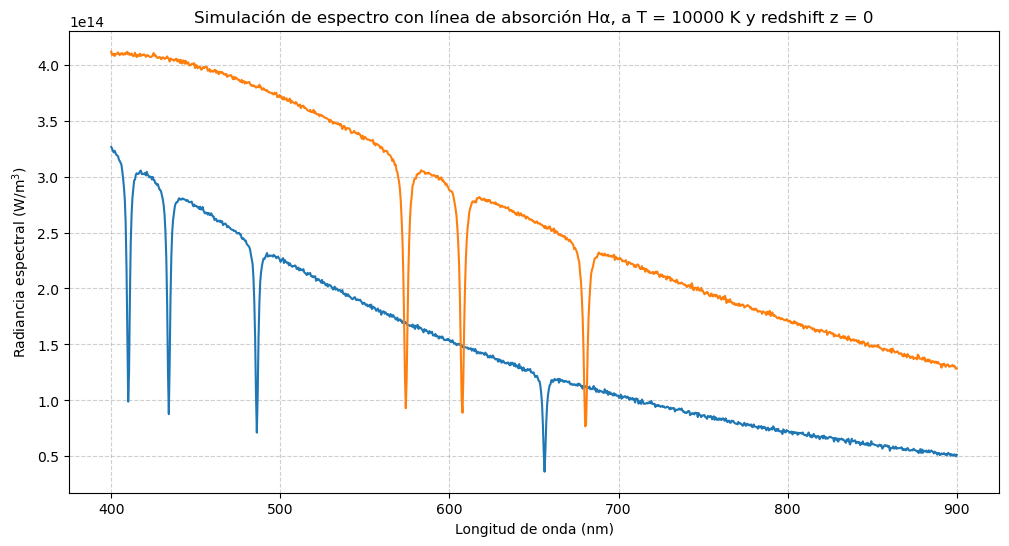

In [7]:
# Graficar
plt.figure(figsize=(12, 6))
plt.plot(lambdaDom * 1e9, BRang)
plt.plot(lambdaDom2 * 1e9, BRang2)
plt.title(f'Simulación de espectro con línea de absorción Hα, a T = {T} K y redshift z = {z}')
plt.xlabel('Longitud de onda (nm)')
plt.ylabel('Radiancia espectral (W/m$^3$)')
plt.grid(True, linestyle='--', alpha=0.6)
# plt.xlim(400, 1000)
plt.show()

SUPER GENERADOR

In [9]:
def spectrum_generator_2(T, z):
    lambda0_data = LambdaDom(z, z_lambda_min, z_lambda_max, N_lambda)
    stardata = H_lines(lambda0_data, blackbody(lambda0_data,T))
    spectrum = spectrum_generator(lambda0_data, stardata, z)
    return z, spectrum

In [10]:
#Domino fijo
lambda_instrument = LambdaDom(0, z_lambda_min, z_lambda_max, N_lambda)

#Número de espectros a generar
N_spectra = 5  

#Rango de parámetros aleatorios
np.random.seed(42)
T_values = np.random.uniform(3000, 15000, N_spectra)
z_values = np.random.uniform(0, 1, N_spectra)

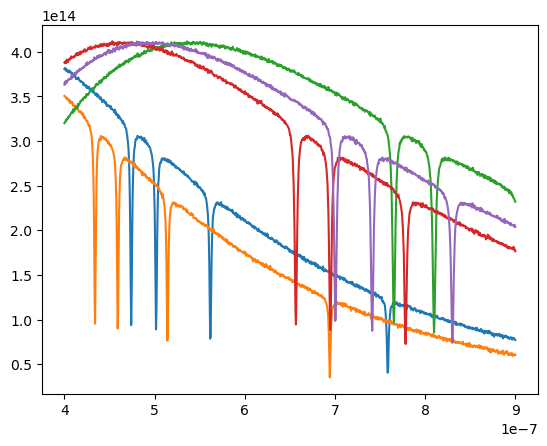

In [16]:
plt.figure()
for i in range(N_spectra):
    # B = spectrum_generator_2(T_values[i],z_values[i])[1]
    B = spectrum_generator_2(T,z_values[i])[1]
    plt.plot(lambda_instrument, B)